In [1]:
import numpy as np
np.set_printoptions(suppress=True, precision=6)
import pandas as pd
import shap
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

data = pd.read_csv('matmulData.csv')

X = data.drop('GPU', axis=1)
y = data['GPU']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_log = np.log(y_train)

cols = ['total global memory(KB)', 'clock rate(KHz)', 'multiprocessor count',
       'async engine count', 'memory bus width', 'memory clock rate (KHz)',
       'L2 cache size (bytes)', 'max threads per SM']

features = ['elements', 'TILE_WIDTH', 'blocks', 'threadsPerBlock',
       'total global memory(KB)', 'clock rate(KHz)', 'multiprocessor count',
       'async engine count', 'memory bus width', 'memory clock rate (KHz)',
       'L2 cache size (bytes)', 'max threads per SM']

device_specs = data[cols].drop_duplicates().to_numpy()

#device_specs[0] = cuda2
#device_specs[1] = cuda3
#device_specs[2] = cuda4
#device_specs[3] = cuda5

In [2]:
model = XGBRegressor(
    n_estimators=10000,        # Reduce the number of trees
    max_depth=8,            # Minimal tree depth
    learning_rate=0.1,     # Decrease learning rate
    # reg_alpha=1.0,          # Add L1 regularization
    # reg_lambda=1.0,         # Add L2 regularization
    # subsample=0.8,
    # colsample_bytree=1, 
    random_state=42
)
model.fit(X_train, y_log)

preds_log = model.predict(X_test)
preds = np.exp(preds_log)
preds[:6], y_test.to_numpy()[:6]

(array([1.74759 , 0.955298, 2.027715, 0.249095, 1.05268 , 1.967315],
       dtype=float32),
 array([1.738132, 0.969744, 1.936126, 0.160792, 1.028465, 1.706879]))

In [5]:
# Normalize time and predictions as a percentage of the maximum execution time for each "problem_size"
X_test["GPU"] = y_test
X_test["pred"] = preds
# Group by "problem_size" and compute normalization factor (max)
grouped_max_time = X_test.groupby("elements")["GPU"].transform("max")

# Normalize actual time as a percentage of the max
X_test["normalized_time"] = (X_test["GPU"] / grouped_max_time) * 100

# Group by "problem_size" and compute normalization factor (max) for predictions
grouped_max_preds = X_test.groupby("elements")["pred"].transform("max")

# Normalize predictions as a percentage of the max
X_test["normalized_pred"] = (X_test["pred"] / grouped_max_time) * 100

# Extract normalized predictions as a NumPy array (if needed)
normalized_preds = X_test["normalized_pred"].values

# # Calculate absolute error
# X_test["absolute_error"] = np.abs(X_test["normalized_pred"] - X_test["normalized_time"])

# # Group by "problem_size" and calculate MAE
# mae_by_group = X_test.groupby("image_size")["absolute_error"].mean()

# # Convert results to a DataFrame for display
# mae_results = mae_by_group.reset_index()
# mae_results.columns = ["image_size", "MAE"]

# # Display the results
# print(mae_results)


In [7]:
X_test['blocks_threads'] = X_test['blocks'] * X_test['threadsPerBlock']

# Sorting first by blocks * threadsPerBlock, then by elements
sorted_df = X_test.sort_values(by=['blocks_threads', 'elements'], ascending=[True, True]).reset_index(drop=True)


sorted_df.head()


,elements,TILE_WIDTH,threadsPerBlock,blocks,total global memory(KB),clock rate(KHz),multiprocessor count,async engine count,memory bus width,memory clock rate (KHz),L2 cache size (bytes),max threads per SM,GPU,pred,normalized_time,normalized_pred,blocks_threads
0,10240,8,64,1638400,12339264,1455000,80,7,3072,850000,4718592,2048,4.077204,2.337651,45.797444,26.257808,104857600
1,10240,8,64,1638400,12492800,1215500,24,2,384,3505000,3145728,2048,8.902689,8.233842,100.000000,92.487134,104857600
2,10240,64,4096,25600,11268608,1635000,68,3,352,7000000,5767168,1024,0.375120,0.358745,4.213558,4.029628,104857600
3,10240,32,1024,102400,11268608,1635000,68,3,352,7000000,5767168,1024,1.733208,1.950338,19.468365,21.907289,104857600
4,10240,32,1024,102400,12339264,1455000,80,7,3072,850000,4718592,2048,1.260673,1.291527,14.160587,14.507155,104857600


In [9]:
sorted_df1024 = sorted_df[sorted_df['elements']==102400]

sorted_aggregated_df = sorted_df.groupby(["elements",'blocks_threads']).mean().reset_index()
sorted_df1024aggregated_df = sorted_df1024.groupby(["elements",'blocks_threads']).mean().reset_index()


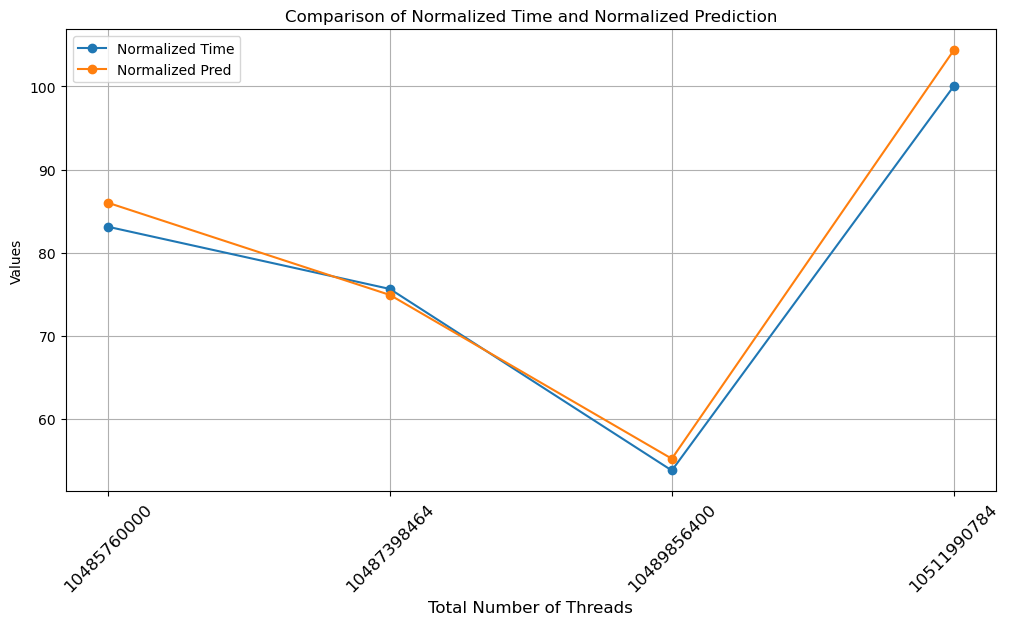

In [11]:
# Plotting the comparison
plt.figure(figsize=(12, 6))
plt.plot(sorted_df1024aggregated_df['normalized_time'], label='Normalized Time', marker='o')
plt.plot(sorted_df1024aggregated_df['normalized_pred'], label='Normalized Pred', marker='o')
plt.xlabel('Total Number of Threads', fontsize=12)
plt.xticks(range(len(sorted_df1024aggregated_df['blocks_threads'])), sorted_df1024aggregated_df['blocks_threads'], fontsize=12, rotation=45)
# plt.xticks(ticks=sorted_df1024aggregated_df['blocks_threads'], labels="threads", )  # Attach x-axis labels

plt.ylabel('Values')
plt.title('Comparison of Normalized Time and Normalized Prediction')
plt.legend()
plt.grid(True)
plt.show()

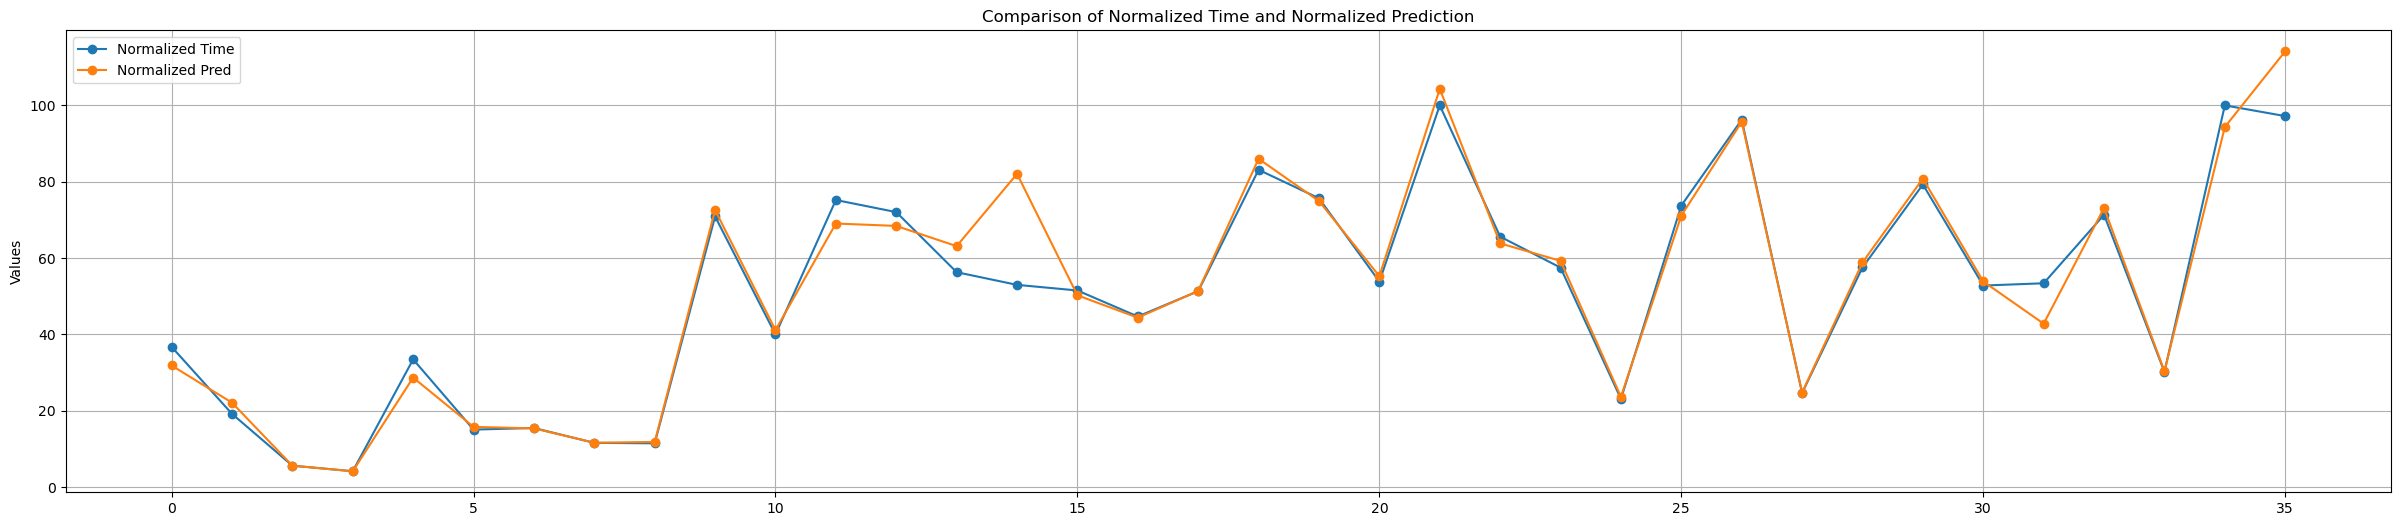

In [13]:
# Plotting the comparison
plt.figure(figsize=(30, 6))
plt.plot(sorted_aggregated_df['normalized_time'], label='Normalized Time', marker='o')
plt.plot(sorted_aggregated_df['normalized_pred'], label='Normalized Pred', marker='o')
# plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Comparison of Normalized Time and Normalized Prediction')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
tile_width = np.array([8, 16, 24, 32, 50, 64, 90, 128, 150, 192])
# blocks = np.array([32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768])
threads = tile_width*tile_width
num_elements = 100000
blocks = ((num_elements+tile_width-1)/tile_width) ** 2

results = []
for i in range(len(tile_width)):
    tile = tile_width[i]
    t = threads[i]
    b = blocks[i]
    input_features = np.concatenate([np.array([num_elements, tile, t, b], dtype='float64'), device_specs[0]]).reshape(-1, 12)
    
    res = np.exp(model.predict(input_features))
    
    results.append([tile, t, b, res[0]])

results = np.array(results)

sorted = results[results[:, 3].argsort()]

min_tile, min_tpb, min_b, min_time = results[np.argmin(results[:, 3])]
print(f'Best Config:')
print(f'Blocks: {int(min_b)} | Threads Per Block: {int(min_tpb)} | Tile Width: {int(min_tile)} | Time: {min_time:.6f}s')

print("\nBest device: cuda2")
print("Device Specs:\n")

for name, spec in zip(cols, device_specs[0]):
    print(f'{name}: {spec}')

Best Config:
Blocks: 611902 | Threads Per Block: 16384 | Tile Width: 128 | Time: 0.133997s

Best device: cuda2
Device Specs:

total global memory(KB): 11268608
clock rate(KHz): 1635000
multiprocessor count: 68
async engine count: 3
memory bus width: 352
memory clock rate (KHz): 7000000
L2 cache size (bytes): 5767168
max threads per SM: 1024


In [17]:
print('Top 5 Best Configurations:')

for s in range(5):
    tile, tpb, nb, time = sorted[s]
    print(f'Blocks: {int(nb)} | Threads Per Block: {int(tpb)} | Tile Width: {int(tile)} | Time: {time:.6f}s')

Top 5 Best Configurations:
Blocks: 611902 | Threads Per Block: 16384 | Tile Width: 128 | Time: 0.133997s
Blocks: 445769 | Threads Per Block: 22500 | Tile Width: 150 | Time: 0.134455s
Blocks: 272304 | Threads Per Block: 36864 | Tile Width: 192 | Time: 0.134768s
Blocks: 4003920 | Threads Per Block: 2500 | Tile Width: 50 | Time: 0.135577s
Blocks: 2444483 | Threads Per Block: 4096 | Tile Width: 64 | Time: 0.137397s


In [19]:
#Compare with Ground Truth for 100k Elements
# ground truth gathered by running many configurations of blocks and threadsPerBlock on CIMS servers
# with fixed number of elements for 20 iterations each and taking their mean stratified by configuration
# note: all GT configurations ran on the system with the best overall performance (cuda4 in this case)

gt = pd.read_csv('matmulGT100k.csv')
gt = gt.groupby(['TILE_WIDTH', 'blocks', 'threadsPerBlock']).mean().reset_index().sort_values('GPU')
gt.head(10)

,TILE_WIDTH,blocks,threadsPerBlock,elements,GPU
0,8,156250000,64,100000.0,0.782049
4,50,4000000,2500,100000.0,0.786267
7,128,611524,16384,100000.0,0.790566
9,192,271441,36864,100000.0,0.796248
2,24,17363889,576,100000.0,0.799077
3,32,9765625,1024,100000.0,0.809410
8,150,444889,22500,100000.0,0.815348
1,16,39062500,256,100000.0,0.823964
6,90,1236544,8100,100000.0,6.655778
5,64,2442969,4096,100000.0,31.857932



Top 5 most important features (XGBoost):
                   Feature  Importance
0               TILE_WIDTH    0.051878
4          clock rate(KHz)    0.043545
3  total global memory(KB)    0.029766
2          threadsPerBlock    0.006503
5     multiprocessor count    0.004263

Top 5 most important features (SHAP):
                   Feature  SHAP_Importance
0               TILE_WIDTH         0.194844
3  total global memory(KB)         0.162933
4          clock rate(KHz)         0.094754
2          threadsPerBlock         0.041255
5     multiprocessor count         0.010677


<Figure size 1000x500 with 0 Axes>

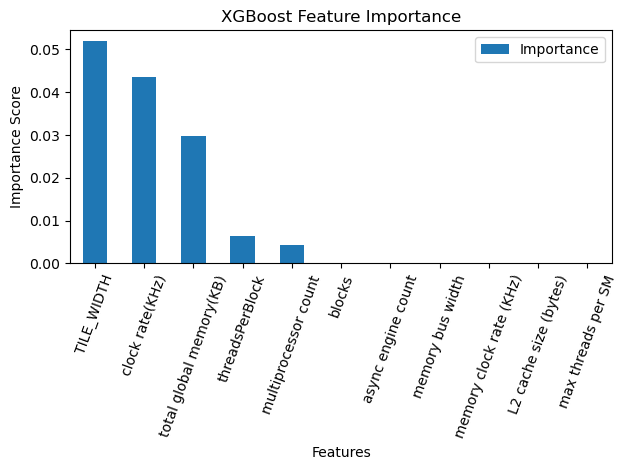

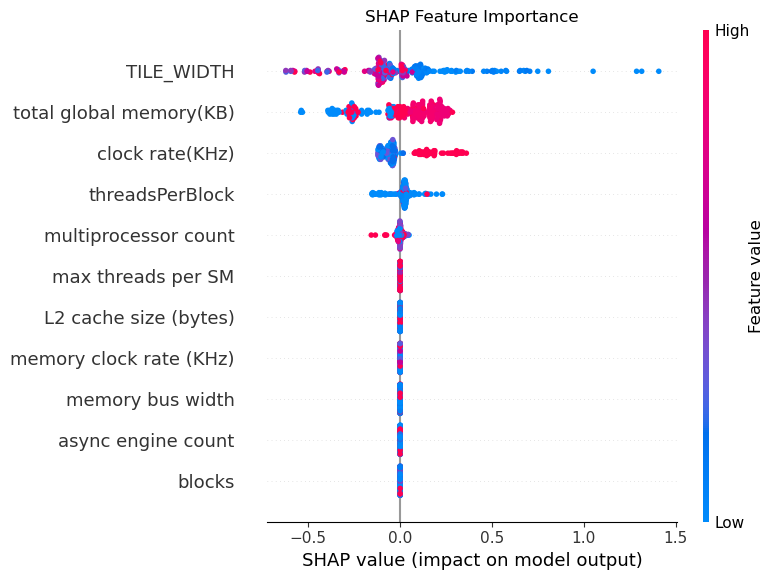

In [21]:
def analyze_feature_importance(model, X_train, exclude, feature_names=None):
    
    if isinstance(exclude, str):
        exclude_idx = feature_names.index(exclude)
    else:
        exclude_idx = exclude
    
    include_names = [name for i, name in enumerate(feature_names) if i != exclude_idx]
    
    importance_values = model.feature_importances_
    importance_dict = {
        name: score for name, score in zip(
            feature_names, 
            importance_values
        ) if name != feature_names[exclude_idx]
    }
    
    importance_df = pd.DataFrame({
        'Feature': list(importance_dict.keys()),
        'Importance': list(importance_dict.values())
    }).sort_values('Importance', ascending=False)
    
    #running shap
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    
    # exclude 'elements'
    if isinstance(X_train, pd.DataFrame):
        X_train_filtered = X_train.drop(columns=[feature_names[exclude_idx]])
    else:
        X_train_filtered = np.delete(X_train, exclude_idx, axis=1)
    
    shap_values_filtered = np.delete(shap_values, exclude_idx, axis=1)
    
    # mean absolute shap values for each input feature
    # absolute value because we want to measure total impact, positive or negative on the comptue time
    mean_shap = pd.DataFrame({
        'Feature': include_names,
        'SHAP_Importance': np.abs(shap_values_filtered).mean(axis=0)
    }).sort_values('SHAP_Importance', ascending=False)
    

    fig_xgb = plt.figure(figsize=(10, 5))
    importance_df.plot(x='Feature', y='Importance', kind='bar')
    plt.title('XGBoost Feature Importance')
    plt.xlabel('Features')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=70)
    plt.tight_layout()
    
    fig_shap = plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values_filtered, X_train_filtered, 
                     feature_names=include_names, show=False)
    plt.title('SHAP Feature Importance')
    plt.tight_layout()
    
    return {
        'xgboost_importance': importance_df,
        'shap_importance': mean_shap,
        'shap_values': shap_values_filtered,
        'figure_xgb': fig_xgb,
        'figure_shap': fig_shap
    }

results = analyze_feature_importance(model, X_train, exclude='elements', feature_names=features)

print("\nTop 5 most important features (XGBoost):")
print(results['xgboost_importance'].head())

print("\nTop 5 most important features (SHAP):")
print(results['shap_importance'].head())

plt.show()
